## Exploring META data and Generating Subfolders for FB_INF project

#### LOADING THE NECESSARY LIBRARIES TO EXPLORE THE METADATA GENERATED

In [1]:

%load_ext autoreload
%autoreload 2

from wormholes import *
from wormholes.perturb import *
from wormholes.tools.triplets_vis_tools import *
import matplotlib.pyplot as plt
import matplotlib.image as img
from argparse import Namespace
import os
import xarray as xr #this is to be able to read the .nc type of file
import shutil

In [2]:
# Set the HOME environment variable to your current working directory
os.environ["HOME"] = "/project/3018078.01/Gaziv/Wormholes_FB"

# Now the `os.path.expanduser("~")` will resolve to this directory
print(os.path.expanduser("~")) 

/project/3018078.01/Gaziv/Wormholes_FB


This next part of the script is loading the meta data file and does some exploration of the variables that have been defined there. 

In [ ]:
#this is the directory where they will find the images (change as you deem necessary)
##TODO: check that it works with a different directory

exp_root = f"{PROJECT_ROOT}/results/cache/gen_v6"
# exp_root = f"{PROJECT_ROOT}/results/cache/placeholder/gen_v4"

# Load the metadata file
metadata = xr.open_dataset(f"{exp_root}/meta.nc")

# Print metadata structure
print(metadata)

# List variables in the dataset
#print(metadata.variables)

<xarray.Dataset>
Dimensions:                                   (image_id: 21735, class_index: 9,
                                               model_subject_name: 7)
Coordinates:
  * image_id                                  (image_id) object '8e5335caf28f...
  * class_index                               (class_index) int64 0 1 2 ... 7 8
  * model_subject_name                        (model_subject_name) object 're...
Data variables: (12/15)
    model_name                                (image_id) object ...
    budget                                    (image_id) float64 ...
    n_iter                                    (image_id) int64 ...
    step_size                                 (image_id) float64 ...
    interp_alpha                              (image_id) float64 ...
    target_class_name                         (image_id) object ...
    ...                                        ...
    budget_usage                              (image_id) float64 ...
    target_image_path   

I am now transforming the .nc file into a Pandas dataframe, as this is the type of structure I am familiar with and allows me to do the selection of relevant information I need for my experiment

In [4]:
#Depending on the size of the meta.nc file. The kernel might get overwhemled when trying to trasnform it to a pandas dataframe. 
#Therefore, the next couple of code lines are to only pass the information that is relevant (reducing the size of df)
selected_vars = ["model_name", "budget", "image_id",'class_index', 'pred_logit',
                 'model_subject_name', 'orig_class_name', 'orig_name']
df = metadata[selected_vars].to_dataframe().reset_index()

# Convert the dataset to a Pandas DataFrame (this is because I am most comfortable using Pandas df)
# df = metadata.to_dataframe().reset_index()

# Inspect the metadata structure
print(df.head())

# Inspect the columns in the Pandas Dataframe
print(df.columns)

#information about the data in the columns
df.info(verbose=False)

                               image_id  class_index  \
0  8e5335caf28fe870801d71262d8c02a4.png            0   
1  8e5335caf28fe870801d71262d8c02a4.png            0   
2  8e5335caf28fe870801d71262d8c02a4.png            0   
3  8e5335caf28fe870801d71262d8c02a4.png            0   
4  8e5335caf28fe870801d71262d8c02a4.png            0   

                      model_subject_name      model_name  budget  pred_logit  \
0     resnet50_robust_mapped_RIN_l2_10_0  contrast_blend    20.0         NaN   
1  resnet50_robust_mapped_RIN_l2_10_0_v2  contrast_blend    20.0    2.041406   
2   resnet50_robust_mapped_RIN_l2_1_0_v2  contrast_blend    20.0         NaN   
3      resnet50_robust_mapped_RIN_l2_3_0  contrast_blend    20.0         NaN   
4   resnet50_robust_mapped_RIN_l2_3_0_v2  contrast_blend    20.0    3.163702   

  orig_class_name                                       orig_name  
0             ANI  ANI/WhatsApp Image 2023-04-30 at 16.53.27.jpeg  
1             ANI  ANI/WhatsApp Image 2023-04-

In [10]:
## EXPLORATION OF V6 (FOR POSSIBLE FUTURE USE)

print(df['budget'].unique())
f_df = df[(df['model_name'] == 'resnet50_robust_mapped_RIN_l2_3_0') & (df['budget'] == 0) & (df['model_subject_name'] == 'resnet50_robust_mapped_RIN_l2_3_0') & (df['orig_class_name'] == 'UNI')] 
print(len(f_df['image_id'].unique())) # displays all the networks available to extract images from

[20. 25. 30. 40. 50.  0.]
45


I am now filtering the dataframe so it only includes the parameters that are relevant for my experiment. 
With the filtered data frame I can then create folders with the relevant images for the experiment (with the correct names)

NOTE: model_name is the variable used to define which model is being used to generate the adversarial images. model_subject_name is all the other models that will be tested on the adversarial images generated by model_name and compare their performances. 

In [15]:
#The following lines of code are ways of probing the df. Not necessary, but useful

# print(df['model_name'].unique()) # displays all the networks available to extract images from
# print(df['model_subject_name'].unique()) #the v2 versions of the networks are just initialized using different seeds
# print(df['budget'].unique()) #all the budget options I can select images from


# Apply filtering

filtered_df = df[(df['model_name'] == 'resnet50_robust_mapped_RIN_l2_3_0') & (df['budget'] == 12.5) & (df['model_subject_name'] == 'resnet50_robust_mapped_RIN_l2_3_0')] 
print(filtered_df.head())
# print(filtered_df.columns)
# print(filtered_df['model_name'])
# print(len(filtered_df['image_id'].unique()))
filtered_df.shape
print(filtered_df['class_index'].unique())

#Code to visualize any image we want on the dataset
# im = img.imread(f"{exp_root}/images/30a0f974d91cf438f69c726c9434678b.png")
# plt.imshow(im)


                                     image_id  class_index  \
2833924  be66c7dd6a847caf27eec8fe652653e2.png            0   
2833932  be66c7dd6a847caf27eec8fe652653e2.png            1   
2833940  be66c7dd6a847caf27eec8fe652653e2.png            2   
2833948  be66c7dd6a847caf27eec8fe652653e2.png            3   
2833956  be66c7dd6a847caf27eec8fe652653e2.png            4   

                        model_subject_name                         model_name  \
2833924  resnet50_robust_mapped_RIN_l2_3_0  resnet50_robust_mapped_RIN_l2_3_0   
2833932  resnet50_robust_mapped_RIN_l2_3_0  resnet50_robust_mapped_RIN_l2_3_0   
2833940  resnet50_robust_mapped_RIN_l2_3_0  resnet50_robust_mapped_RIN_l2_3_0   
2833948  resnet50_robust_mapped_RIN_l2_3_0  resnet50_robust_mapped_RIN_l2_3_0   
2833956  resnet50_robust_mapped_RIN_l2_3_0  resnet50_robust_mapped_RIN_l2_3_0   

         budget  pred_logit orig_class_name  \
2833924    12.5   12.555303            frog   
2833932    12.5    4.525248            frog   

In [16]:
#This is to try to understand how the logits are changing as a function of individual images
#I am only doing some visualizations

#print(filtered_df.shape)
filtered_df_2 = filtered_df[(filtered_df['orig_class_name'] == 'dog')]
print(filtered_df_2.head(36))


                                     image_id  class_index  \
2856964  0d8e3df1925407933a062be622a59757.png            0   
2856972  0d8e3df1925407933a062be622a59757.png            1   
2856980  0d8e3df1925407933a062be622a59757.png            2   
2856988  0d8e3df1925407933a062be622a59757.png            3   
2856996  0d8e3df1925407933a062be622a59757.png            4   
2857004  0d8e3df1925407933a062be622a59757.png            5   
2857012  0d8e3df1925407933a062be622a59757.png            6   
2857020  0d8e3df1925407933a062be622a59757.png            7   
2857028  0d8e3df1925407933a062be622a59757.png            8   
2857036  0d8e3df1925407933a062be622a59757.png            9   
2857044  0d8e3df1925407933a062be622a59757.png           10   
2857052  0d8e3df1925407933a062be622a59757.png           11   
2857060  799d0ce0ad49204ebaf064ec42902733.png            0   
2857068  799d0ce0ad49204ebaf064ec42902733.png            1   
2857076  799d0ce0ad49204ebaf064ec42902733.png            2   
2857084 

In the code above, the filtered_df now consists of only rows with X (number of classes) classes x 60 images x which of the X classes the current image is classified as (this information might be relevant then to probe whether certain classes are more likely to be transformed into other classes). 

I will create a histogram per class to see the distribution of the selected classes and assess whether there is any detected systematicity in the PGD


=== max_class_per_image for bear ===
                                     image_id  class_index
2871364  036fd950d76a08f3d0b5e0bfdb7158f7.png            0
2873124  0b850620fdc9a462d6e93d96f46ef0b4.png            4
2869236  0ca5bd7309ec82c71aa97bcf38105f8f.png           10
2870268  113022afc89eeee4648f61173503df53.png            7
2870596  1d06f2ba8f1ae4839d317a7b304c02bb.png            0

=== counts for bear (before mapping) ===
0     34
4      4
5     13
7      1
8      1
10     7
Name: class_index, dtype: int64


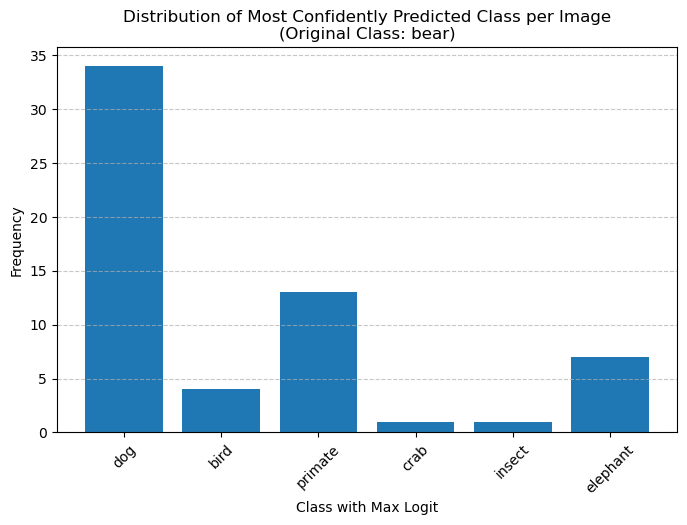


=== max_class_per_image for bird ===
                                     image_id  class_index
2849924  02d8bfc5cb1ce283cc47348322998617.png            8
2847428  0360334aaa63297758264b79d905b220.png            8
2846988  0429b69b40a4de2eec4f9320d895817c.png            1
2848580  12178d3b68a063c949835ada68cb53b5.png            8
2847116  1416f1d24d00048bff0d820545b160ea.png            5

=== counts for bird (before mapping) ===
0     14
1      5
2      1
3      2
5     14
7      4
8     11
9      4
11     5
Name: class_index, dtype: int64


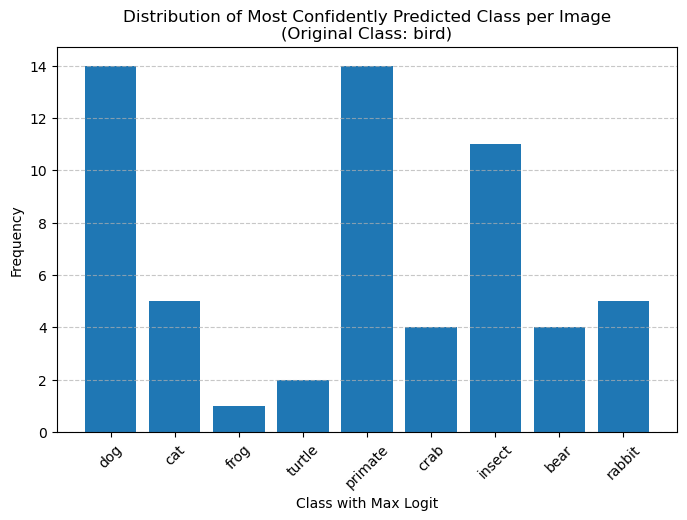


=== max_class_per_image for cat ===
                                     image_id  class_index
2867692  090ed7dce4893822bd5e820b63a5f4de.png            9
2864740  0a0b721e015326fb0b8053f9a2645f99.png            0
2865604  0af7c6ad630f54b630c6e46f4d7e70fe.png            0
2862980  0efbdfef354c0644a30fa47d11f2e2de.png            8
2864956  0fe879a57f7e29b4c34d30a1abe9b0eb.png            3

=== counts for cat (before mapping) ===
0     38
1      1
2      4
3      2
4      2
5      6
8      2
9      2
10     3
Name: class_index, dtype: int64


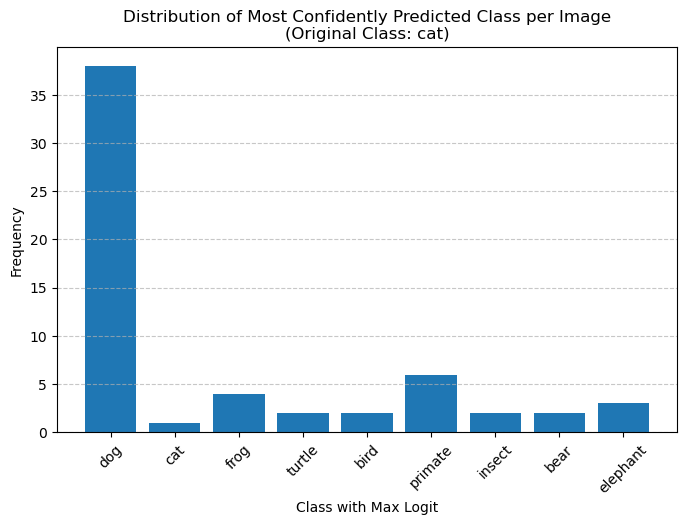


=== max_class_per_image for crab ===
                                     image_id  class_index
2853284  010c150753f4bebf69ff1ce6d4e7da8a.png            8
2855972  01ada67aabed97c8d15c4b00139a1489.png            8
2855428  02ce31c00684ffb2bc7297b819b0e903.png            0
2852980  04edbfd8cc5bff9f96eee1054ed3c2fd.png            6
2853916  09d9a40cd76953457f9a417bab7f3744.png            3

=== counts for crab (before mapping) ===
0     8
1     1
2     8
3     8
4     7
5     2
6     8
8    18
Name: class_index, dtype: int64


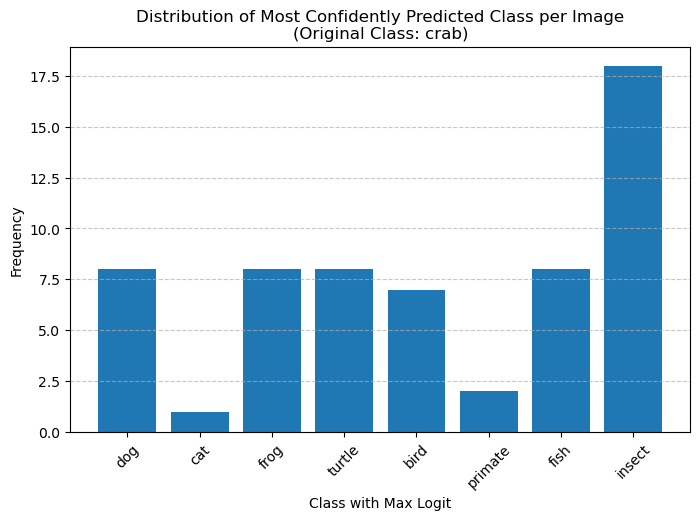


=== max_class_per_image for dog ===
                                     image_id  class_index
2858508  05a39cbb61be8757afc5663d10e84cc9.png            1
2861580  06b4b18573b966059b386942203ff285.png            1
2858028  06b6653d98fa4e7a9e008d8326257e83.png            1
2856972  0d8e3df1925407933a062be622a59757.png            1
2858796  0ebe809031595a127e6883a0d00ee4f7.png            1

=== counts for dog (before mapping) ===
0      1
1     38
4      6
5      4
6      1
8      3
9      5
11     2
Name: class_index, dtype: int64


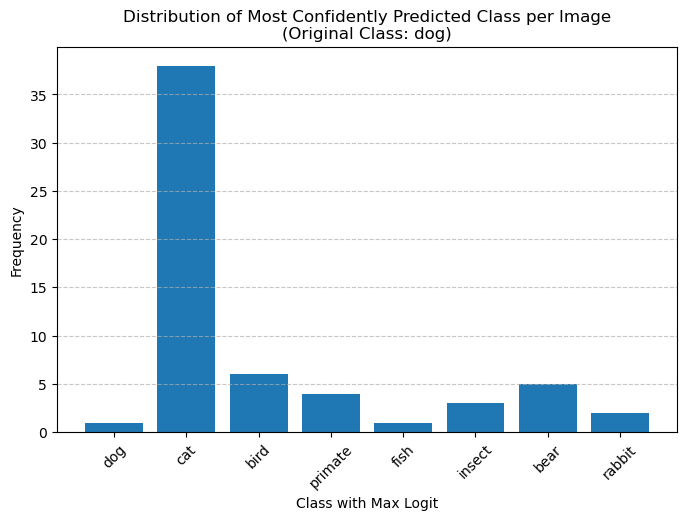


=== max_class_per_image for elephant ===
                                     image_id  class_index
2893324  06d7adaf4740311fc76463e3d3c32b14.png            9
2896996  0d963d184a232459ab71b28e2e69c92d.png            0
2896420  1331ebfd0cfc7b822e2acd9fe30f53fb.png            0
2893060  14177103102953919000c4189f7c4f81.png            0
2892524  1b3c2eb7d0b8f9ee45b9be2a79aed223.png            5

=== counts for elephant (before mapping) ===
0    27
1     1
4     6
5    13
8     2
9    11
Name: class_index, dtype: int64


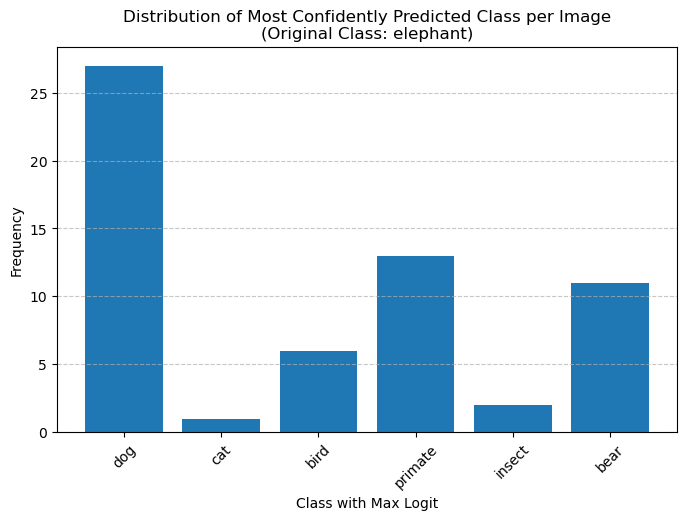


=== max_class_per_image for fish ===
                                     image_id  class_index
2900860  023ab747b88bf940a2bd3dee020b1912.png            3
2902780  03560c501bc1de833c466739f01a6c3f.png            3
2902404  1c451da5b1332d31bbc4d11fcf587a68.png            4
2901164  1cf681b8975dfa5b190e116585fc97a7.png            5
2902236  271d3a1b969dfe3f22bbc55e426da2e1.png            7

=== counts for fish (before mapping) ===
0     4
2     5
3    12
4    11
5     7
6     2
7     8
8     8
9     3
Name: class_index, dtype: int64


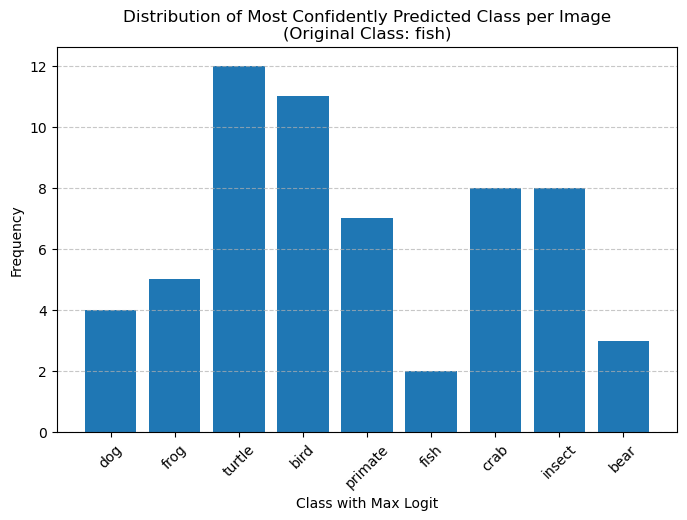


=== max_class_per_image for frog ===
                                     image_id  class_index
2834140  002ebecda11159caad338a27972ad918.png            3
2837244  00743bae16790599f32bb11232e070dd.png            7
2838396  02861b90a296b7c35bf10dea400558f2.png            7
2835332  04de2e95a17935b08fee0c9d5d5cb5b4.png            8
2836468  0b2db7312f4b2362e8f22a2a792db733.png            6

=== counts for frog (before mapping) ===
0      2
3      8
4      5
6      5
7      8
8     31
11     1
Name: class_index, dtype: int64


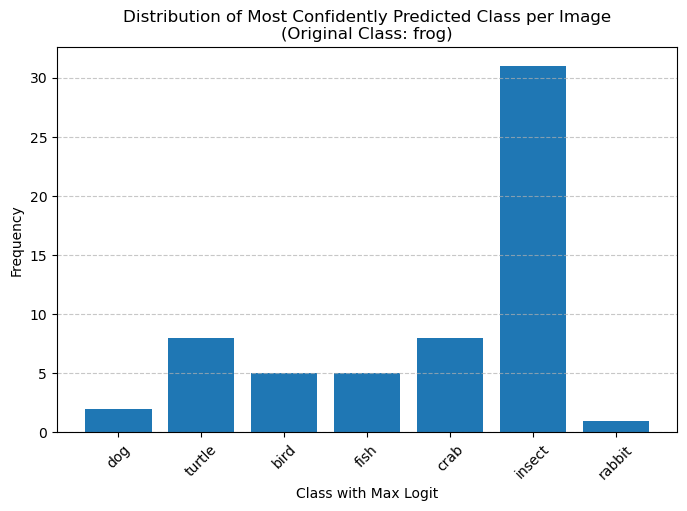


=== max_class_per_image for insect ===
                                     image_id  class_index
2878100  0d77ad676832c1737cec318130f706c6.png            2
2879364  1621139085f580845ab3bbf17914e31a.png            4
2875044  1763fab7a8bd019d0a74d2f35e32c9df.png            4
2878428  17fa32906a778b6687efc048481a30d0.png            7
2879564  2686a03932b2c0f070d27a09473bc056.png            5

=== counts for insect (before mapping) ===
0     2
2    14
3     5
4    25
5     4
6     1
7     7
8     2
Name: class_index, dtype: int64


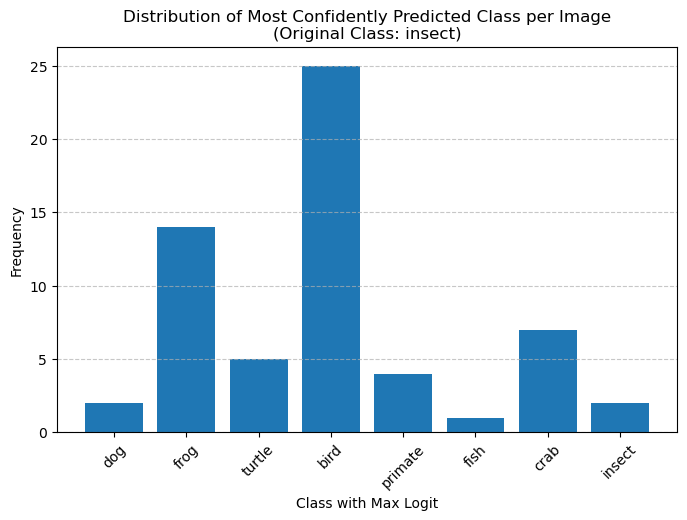


=== max_class_per_image for primate ===
                                     image_id  class_index
2889700  073e7e9873471bd7648b8f32cb4ec23c.png            0
2887588  0f748fdbdafec6d890e3a2f2bc2322c6.png            0
2887108  0f75a581cade9b6de06a165b398a2d4b.png            0
2891044  1667aefdaa9f889771977fbb79a28deb.png            0
2888068  19f940cefe5b7963c2f4eec4b77106ed.png            0

=== counts for primate (before mapping) ===
0     36
1      2
2      1
3      6
4      4
6      2
8      3
9      3
10     3
Name: class_index, dtype: int64


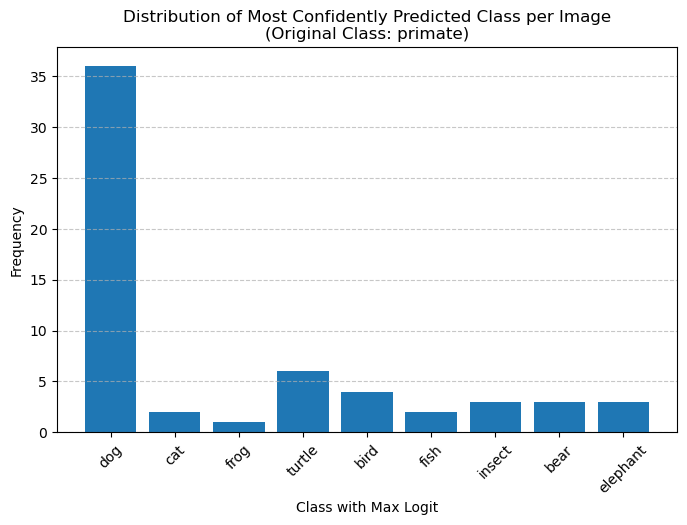


=== max_class_per_image for rabbit ===
                                     image_id  class_index
2885604  04037eecf2ccf7b6c464405d3b892729.png            4
2881092  0565fe3aafcdad6d5d7ae0a9b6d31e7d.png            4
2884932  086fb461e16a1095a9faf1c106d062ad.png            4
2884740  092599318c3bfdcd9a3ba961f1396a25.png            4
2883780  0a1d9a912c253dd2449a2b27b1900755.png            4

=== counts for rabbit (before mapping) ===
0    10
1     3
2     1
3     1
4    37
5     7
8     1
Name: class_index, dtype: int64


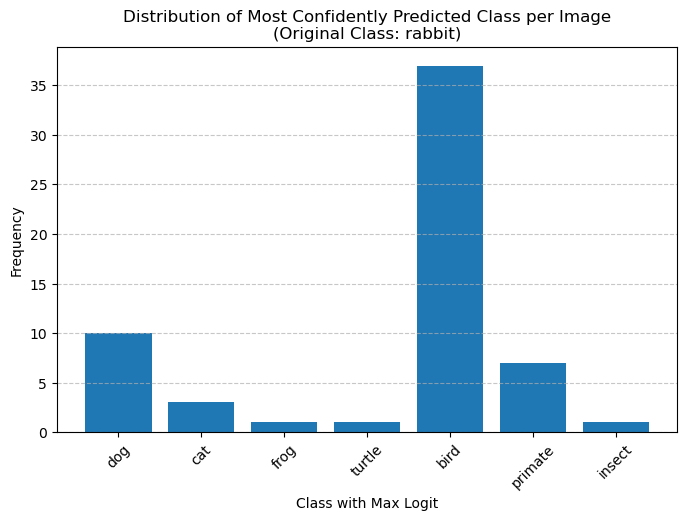


=== max_class_per_image for turtle ===
                                     image_id  class_index
2842020  00e7b6c763a705600c97bd21d688419e.png            4
2840028  017a84c6b353e79ed624f15d233811b0.png            7
2844452  01de84dbca160d040ef8331e11006b88.png            8
2844820  077d4cf598ac4d0ec6a4858e1449ce41.png            6
2840644  07bbcb9696521fb1bbcc74d4c1739574.png            0

=== counts for turtle (before mapping) ===
0     12
4     13
5      1
6     15
7     12
8      6
11     1
Name: class_index, dtype: int64


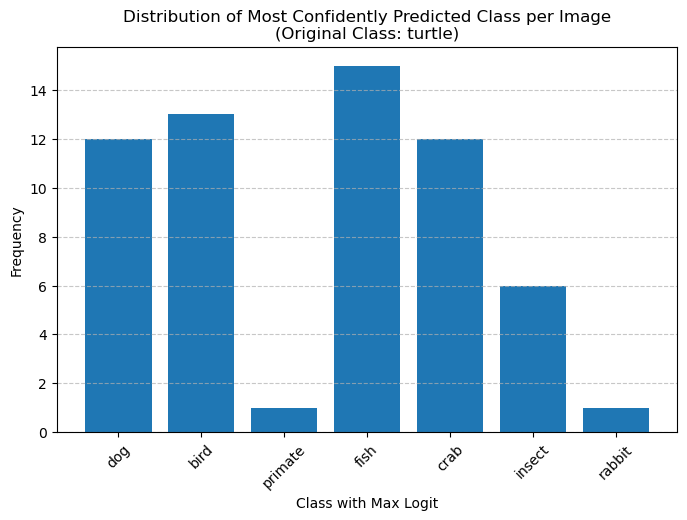

In [9]:

# Mapping of class_index to labels
# class_labels = {
#     0: "dog", 1: "cat", 2: "frog", 3: "turtle", 4: "bird",
#     5: "primate", 6: "fish", 7: "crab", 8: "insect"
# }

class_labels = { 0: 'dog', 1: 'cat', 
                   2: 'frog', 3: 'turtle', 4: 'bird', 
                   5: 'primate', 6: 'fish', 7: 'crab', 
                   8: 'insect', 9: 'bear', 10: 'elephant', 11: 'rabbit'}


def plot_max_class_histogram_per_orig_class(df):
    """
    Plots histograms of the most frequently predicted class_index per image, separately for each orig_class_name.

    Parameters:
        df (pd.DataFrame): A DataFrame containing 'orig_class_name', 'image_id', 'class_index', and 'pred_logit'.

    Returns:
        None
    """
    # Loop over each original class
    for orig_class, sub_df in df.groupby("orig_class_name"):
        # Find the class_index with the highest pred_logit for each image
        max_class_per_image = sub_df.loc[sub_df.groupby("image_id")["pred_logit"].idxmax(), ["image_id", "class_index"]]

        # Print the DataFrame containing only the highest logit per image
        print(f"\n=== max_class_per_image for {orig_class} ===")
        print(max_class_per_image.head())  # Print first few rows to inspect

        # Count occurrences of each class_index being the max
        class_counts = max_class_per_image["class_index"].value_counts().sort_index()

        # Print the counts before mapping to class labels
        print(f"\n=== counts for {orig_class} (before mapping) ===")
        print(class_counts)

        # Map class_index to class labels
        class_labels_mapped = [class_labels[idx] for idx in class_counts.index]

        # Plot histogram
        plt.figure(figsize=(8, 5))
        plt.bar(class_labels_mapped, class_counts.values)
        plt.xlabel("Class with Max Logit")
        plt.ylabel("Frequency")
        plt.title(f"Distribution of Most Confidently Predicted Class per Image\n(Original Class: {orig_class})")
        plt.xticks(rotation=45)  # Rotate labels for readability
        plt.grid(axis="y", linestyle="--", alpha=0.7)
        plt.show()


plot_max_class_histogram_per_orig_class(filtered_df)


### Understanding logit distributions 
The plots above show me over all the images, which class the network selected as the most likely. 
I now want to plot across all images, the mean logit for each class (this will give me insights into how the cross entropy loss is being maximized by the network)


=== Mean logits for bear (before mapping) ===
class_index
0     10.588592
1      3.548129
2      0.778216
3      2.128696
4      4.634392
5      7.398275
6      1.637459
7      0.192436
8      2.322411
9      6.733475
10     3.942143
11     2.191990
Name: pred_logit, dtype: float64


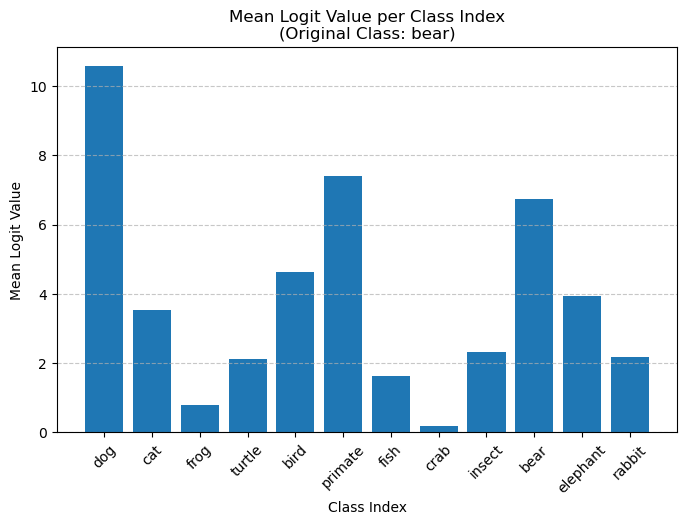


=== Mean logits for bird (before mapping) ===
class_index
0     6.157148
1     4.290242
2     2.645958
3     3.515897
4     4.721964
5     5.484310
6     1.950015
7     2.752664
8     4.785567
9     3.620601
10    0.644972
11    4.249721
Name: pred_logit, dtype: float64


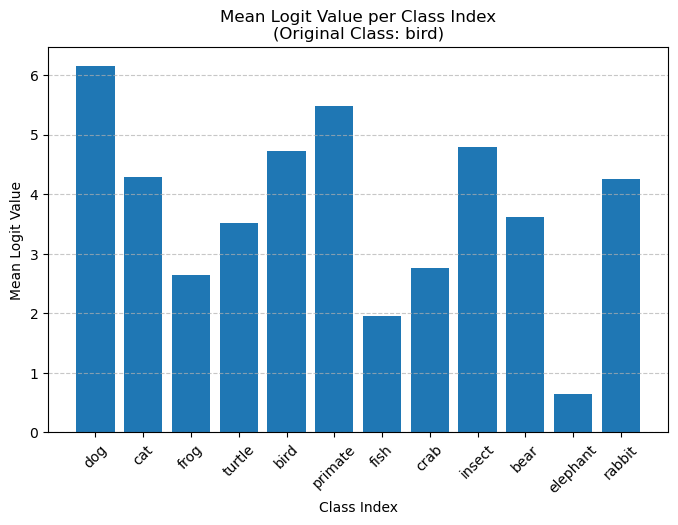


=== Mean logits for cat (before mapping) ===
class_index
0     10.987504
1      5.977882
2      2.493328
3      2.944988
4      3.377274
5      4.795755
6      2.390175
7      1.637840
8      2.107257
9      3.380035
10     0.647345
11     2.911233
Name: pred_logit, dtype: float64


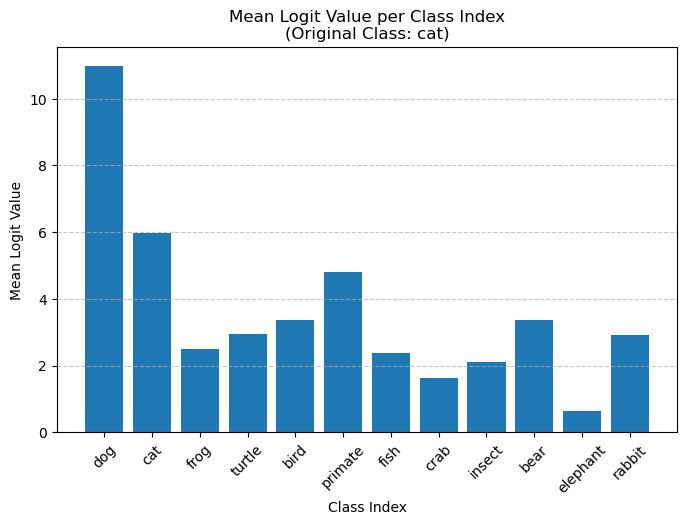


=== Mean logits for crab (before mapping) ===
class_index
0     4.061165
1     2.417430
2     5.539253
3     6.649422
4     4.789483
5     3.364910
6     5.538008
7     5.855419
8     7.765281
9     0.847576
10   -0.337140
11    1.125269
Name: pred_logit, dtype: float64


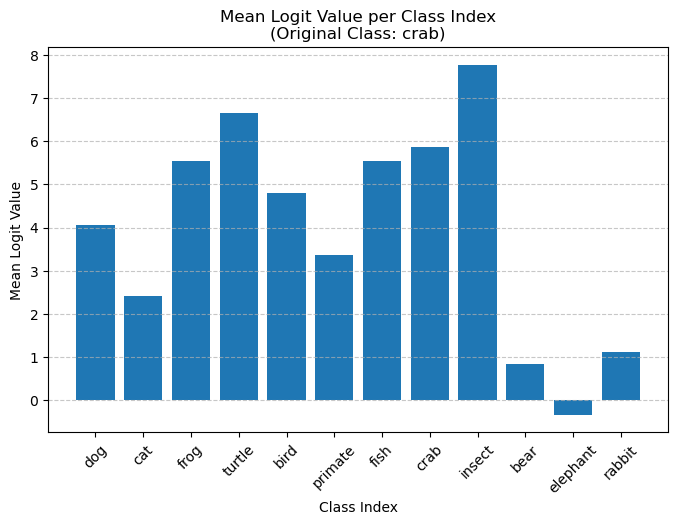


=== Mean logits for dog (before mapping) ===
class_index
0     7.416159
1     9.409636
2     0.020318
3     1.412967
4     4.059840
5     5.065785
6     1.424015
7     0.374746
8     1.811297
9     2.364144
10   -1.155426
11    4.538600
Name: pred_logit, dtype: float64


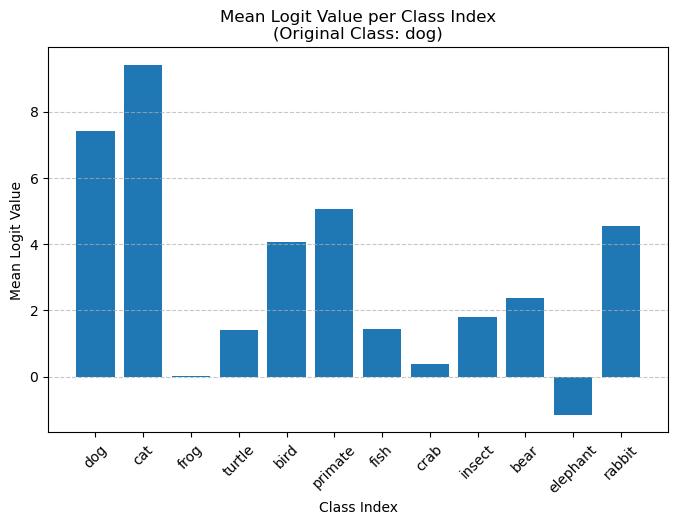


=== Mean logits for elephant (before mapping) ===
class_index
0     10.482309
1      4.032224
2      0.248716
3      1.346585
4      4.227874
5      7.254247
6      1.845779
7      0.338503
8      1.604266
9      6.396801
10     5.694814
11     2.632673
Name: pred_logit, dtype: float64


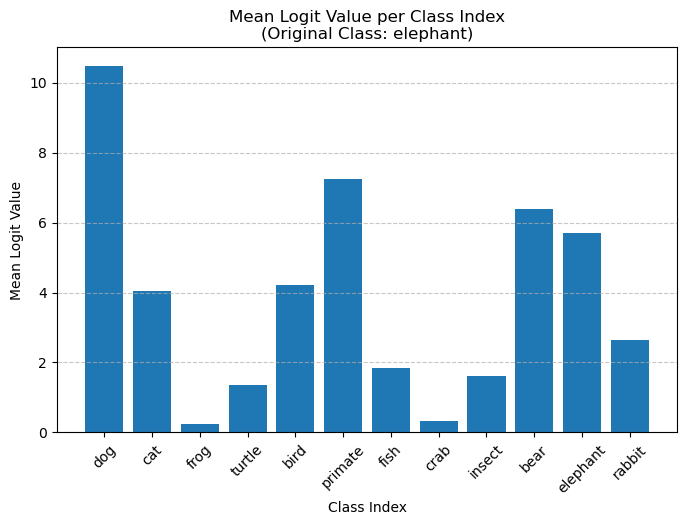


=== Mean logits for fish (before mapping) ===
class_index
0     3.986574
1     2.468185
2     4.346077
3     6.048218
4     5.557789
5     4.703944
6     5.798343
7     4.580376
8     5.051429
9     2.689569
10    0.285819
11    1.909414
Name: pred_logit, dtype: float64


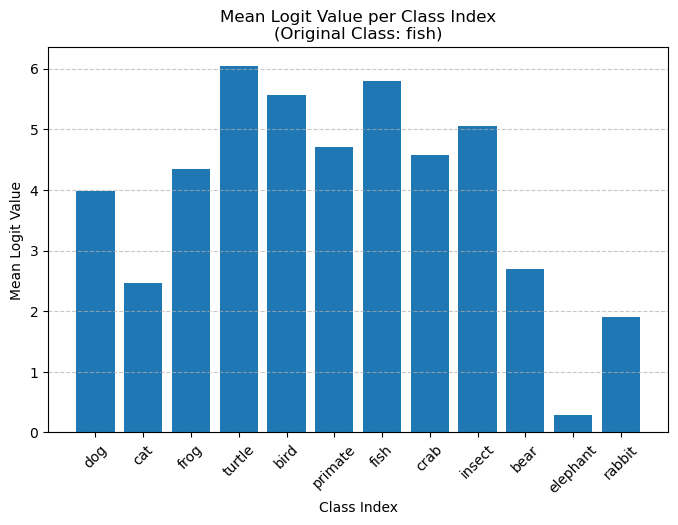


=== Mean logits for frog (before mapping) ===
class_index
0      2.199546
1      1.634307
2      7.093024
3      6.675887
4      5.545831
5      3.081018
6      5.074241
7      6.426355
8     11.429252
9      0.313899
10    -0.563123
11     1.475320
Name: pred_logit, dtype: float64


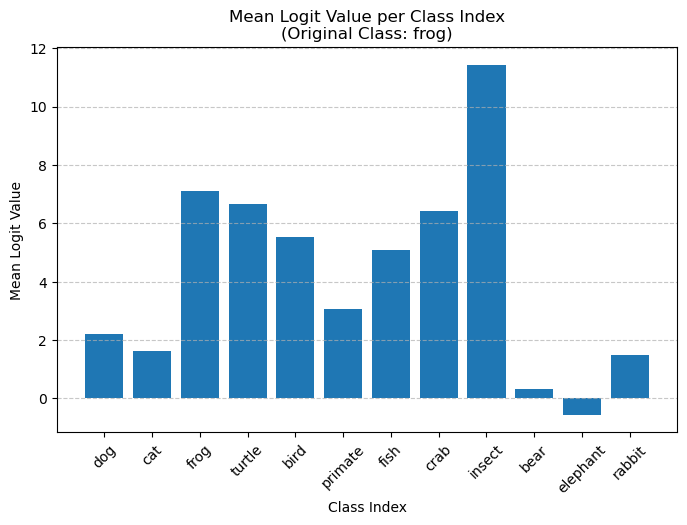


=== Mean logits for insect (before mapping) ===
class_index
0     2.982434
1     1.492601
2     6.747257
3     4.539530
4     9.095237
5     3.495119
6     4.055015
7     4.694214
8     7.518054
9     0.468676
10   -0.489049
11    1.843362
Name: pred_logit, dtype: float64


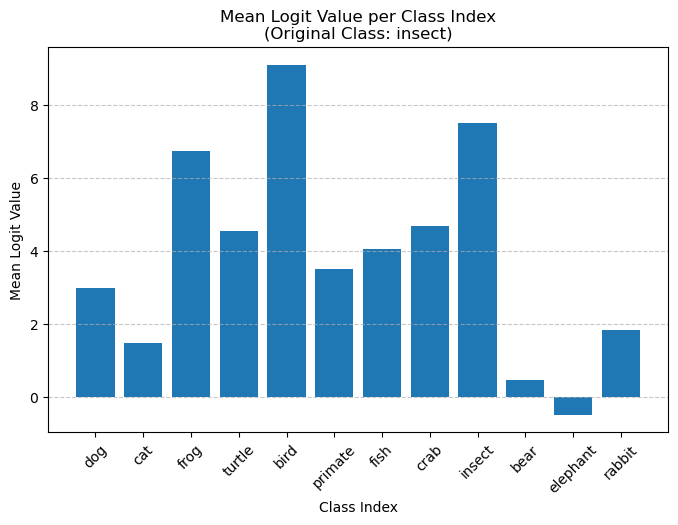


=== Mean logits for primate (before mapping) ===
class_index
0     10.023392
1      3.818331
2      1.624493
3      3.624686
4      3.695230
5      5.041691
6      2.476169
7      1.459146
8      3.030257
9      3.961308
10     2.525977
11     2.164597
Name: pred_logit, dtype: float64


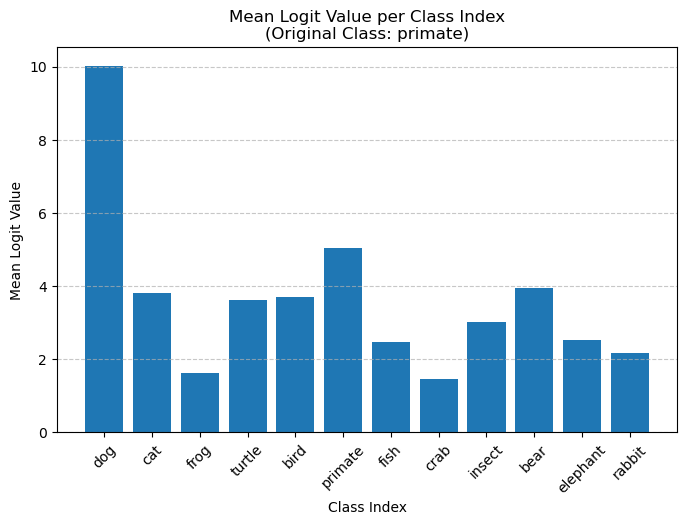


=== Mean logits for rabbit (before mapping) ===
class_index
0      5.977765
1      5.034613
2      2.461875
3      3.430988
4     12.371297
5      5.323815
6      2.681412
7      2.151908
8      3.039502
9      2.341827
10     1.290647
11     5.418418
Name: pred_logit, dtype: float64


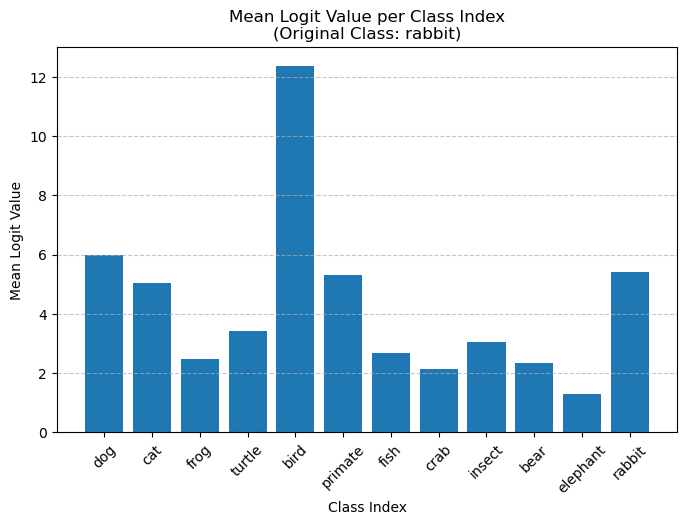


=== Mean logits for turtle (before mapping) ===
class_index
0     4.973279
1     2.161253
2     2.512722
3     5.120861
4     6.194622
5     2.214587
6     6.079119
7     5.315419
8     5.473867
9     2.078609
10    0.944807
11    1.963937
Name: pred_logit, dtype: float64


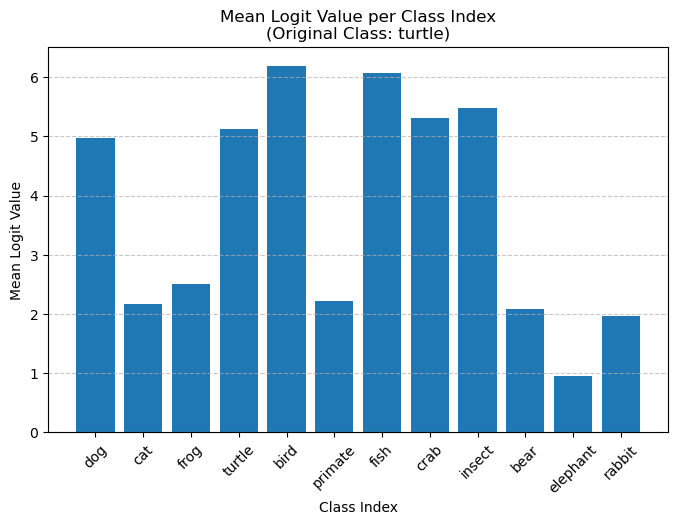

In [10]:

def plot_mean_logit_histogram_per_orig_class(df):
    """
    Plots histograms of the mean logit value per class_index for all images belonging to a specific orig_class_name.

    Parameters:
        df (pd.DataFrame): A DataFrame containing 'orig_class_name', 'image_id', 'class_index', and 'pred_logit'.

    Returns:
        None
    """
    for orig_class, sub_df in df.groupby("orig_class_name"):
        # Compute mean logit per class_index
        mean_logit_per_class = sub_df.groupby("class_index")["pred_logit"].mean()
        
        # Print the mean logits before mapping to class labels
        print(f"\n=== Mean logits for {orig_class} (before mapping) ===")
        print(mean_logit_per_class)
        
        # Map class_index to class labels
        class_labels_mapped = [class_labels[idx] for idx in mean_logit_per_class.index]
        
        # Plot histogram
        plt.figure(figsize=(8, 5))
        plt.bar(class_labels_mapped, mean_logit_per_class.values)
        plt.xlabel("Class Index")
        plt.ylabel("Mean Logit Value")
        plt.title(f"Mean Logit Value per Class Index\n(Original Class: {orig_class})")
        plt.xticks(rotation=45)
        plt.grid(axis="y", linestyle="--", alpha=0.7)
        plt.show()

# Call the function
plot_mean_logit_histogram_per_orig_class(filtered_df)

Now, I want to generate code that creates a new folder with all my perturbed images. 
I will devise a specific form of naming them that will make it easier for me to use in the actual experiment. 

naming convention = original/perturbed_imgclass_budget_imgnumber

I will create first an overall folder, then a folder with subfolders per each class (easier for manipulation of images)

I will then create a final folder with only the selected images

In [10]:
#Creating a new folder with images per class, renamed and easy for me to visualize and filter out later.

output_folder_root = "/project/3018078.01/FB_INF/stimulus_set"

def folder_per_class (df, pert_or_orig):
    """
    Generates folders in the output_folder_root for each of the Restricted ImageNet classes and provides a specific naming convention. 
    It has both the original image (taken from Imagenet validation set) as well as the perturbed image (budget defined above in the notebook)

    Parameters:
        df (pd.DataFrame): A DataFrame of the MetaData containing 'orig_class_name', 'image_id', 'class_index', and 'pred_logit'.
        If the notebook is being followed sequentially. This df should be the filtered df, using the filters desired.
        pert_or_orig (string): A string indicating which images you want the function to generate. Because the dataframe for the 
        origin images that have been cropped is different than the df for the perturbed. The function is divided in two. 

    Returns:
        None

    Output:
        In the output_folder_root you should see your new folders with the images named according to the description:
        1. original_orig_class_name_budget_number -- for the original ilsrvc val dataset
        2. perturbed_orig_class_name_budget_number -- for the perturbed genv4 images

        number is just a numebr from image 0 to the maximum image generated
    """
    # Loop over each original class
    for orig_class, sub_df in df.groupby("orig_class_name"):
        #create a folder in the directory where I will store the images
        folder_dir_path = os.path.join(output_folder_root, str(orig_class))
        
        # Create the folder if it doesn't exist
        os.makedirs(folder_dir_path, exist_ok=True)
        sub_df = sub_df[sub_df['class_index'] == 0]

        for i, row in enumerate(sub_df.itertuples(index=False)):
              if pert_or_orig == 'perturbed':
                #create a file name (according to my naming convention) for perturbed images and cpy them to the output_folder_root
                file_name = f"perturbed_{row.orig_class_name}_{row.budget}_{i+1}.png"
                destination_path = os.path.join(folder_dir_path, file_name)
                source_path = os.path.join(exp_root, f'images/{row.image_id}')
                shutil.copy(source_path, destination_path)
              elif pert_or_orig == 'original':
                file_name_og = f"original_{row.orig_class_name}_{row.budget}_{i+1}.JPEG"
                destination_path_og = os.path.join(folder_dir_path, file_name_og)
                source_path_og = os.path.join(os.path.expanduser('~'), f'data/{row.orig_name}')
                shutil.copy(source_path_og, destination_path_og)
              else:
                print("Insert a valid option: 'perturbed' or 'original' ")

folder_per_class(filtered_df, 'perturbed')

